# Embeddings de palabras

> Cómo representar cada palabra con un vector denso que recoge su significado a partir de los contextos en que aparece: Word2Vec (CBOW y *skip-gram*) entrenado sobre reseñas de Yelp, vectores GloVe preentrenados, palabras más parecidas, analogías, evaluación con WordSim-353 y las analogías de Google y visualización con t-SNE. Con los errores típicos: entrenar dos veces sin querer, creer que una semilla basta para reproducir el modelo, lematizar sin categoría gramatical y leer la similitud como sinonimia.
>
> **Requisitos previos:** [Representación vectorial y TF-IDF](03-representacion-vectorial-tfidf.ipynb) · [N-gramas y colocaciones](02-n-gramas-y-colocaciones.ipynb) · **Relacionado:** [Detección de temas](05-deteccion-de-temas.ipynb) · [Modelos de lenguaje preentrenados](10-modelos-de-lenguaje-preentrenados.ipynb)

## 1. Idea clave

En la [bolsa de palabras](03-representacion-vectorial-tfidf.ipynb) cada palabra es una dimensión independiente: *tasty* y *delicious* son tan distintas como *tasty* y *parking*. Un **embedding de palabra** (*word embedding*) es un vector denso de unas 100–300 dimensiones, aprendido de un corpus, en el que las palabras que aparecen en **contextos parecidos** quedan cerca. Así, un modelo que ha visto *tasty* sabe algo de *delicious* aunque no la haya visto en su conjunto de entrenamiento.

Se entrenan sin etiquetas, solo con texto: **Word2Vec** aprende a predecir las palabras vecinas y **GloVe** factoriza la matriz de coocurrencias. Se pueden entrenar sobre el corpus propio (capturan la jerga del dominio) o descargar ya entrenados sobre miles de millones de palabras (más generales y robustos). Sus límites: un solo vector por palabra, aunque tenga varios sentidos (*bank*, *light*), y no distinguen bien los antónimos, que aparecen en los mismos contextos. Los [modelos de lenguaje preentrenados](10-modelos-de-lenguaje-preentrenados.ipynb) resuelven lo primero con embeddings **contextuales**.

## 2. Conceptos importantes

### 2.1. Hipótesis distribucional

«Conocerás una palabra por las compañías que frecuenta» (Firth, 1957). Si *waiter* y *waitress* aparecen rodeadas de las mismas palabras (*our*, *was*, *friendly*, *took our order*), su significado debe de ser parecido. Los embeddings convierten esta idea en geometría: cada palabra $w$ tiene un vector $\mathbf{v}_w \in \mathbb{R}^d$, y la similitud entre palabras se mide con el **coseno** entre sus vectores (como entre documentos en [TF-IDF](03-representacion-vectorial-tfidf.ipynb)).

### 2.2. Word2Vec

Mikolov et al. (2013) propusieron dos arquitecturas, ambas una red de una sola capa lineal:

- **CBOW** (*continuous bag of words*): predice la palabra central a partir de la media de los vectores de su ventana de contexto. Rápido; bueno con palabras frecuentes.
- ***Skip-gram***: predice cada palabra del contexto a partir de la central. Más lento; mejor con palabras poco frecuentes y corpus pequeños.

En *skip-gram*, la probabilidad de ver la palabra de contexto $c$ junto a la central $w$ es

$$
P(c \mid w) = \frac{\exp(\mathbf{u}_c \cdot \mathbf{v}_w)}{\sum_{c' \in V} \exp(\mathbf{u}_{c'} \cdot \mathbf{v}_w)}
$$

donde $\mathbf{v}_w$ es el vector de $w$ como palabra central, $\mathbf{u}_c$ el de $c$ como contexto y $V$ el vocabulario. El denominador recorre todo el vocabulario y es carísimo, así que se usa **muestreo negativo** (*negative sampling*): para cada par real $(w, c)$ se toman $k$ palabras al azar como ejemplos negativos y se entrena un clasificador logístico que distinga los pares reales de los inventados. Los vectores $\mathbf{v}_w$ que salen del entrenamiento son los embeddings.

Los hiperparámetros clave son el tamaño del vector $d$, la **ventana** (cuántas palabras a cada lado cuentan como contexto: ventanas cortas dan vecinos sintácticos y sustituibles; largas, vecinos temáticos), la frecuencia mínima y el número de épocas.

### 2.3. GloVe y FastText

- **GloVe** (*global vectors*, Pennington et al., 2014) parte de la matriz de coocurrencias $X$ de todo el corpus, donde $X_{ij}$ cuenta cuántas veces aparece $j$ en el contexto de $i$, y ajusta los vectores para que $\mathbf{w}_i\cdot\tilde{\mathbf{w}}_j + b_i + \tilde b_j \approx \log X_{ij}$, con $b_i$ y $\tilde b_j$ términos de sesgo. En la práctica da vectores de calidad parecida a Word2Vec; Stanford publica versiones entrenadas con Wikipedia, Common Crawl y Twitter.
- **FastText** (Bojanowski et al., 2017) representa cada palabra como la suma de los vectores de sus n-gramas de caracteres, así que puede construir un vector para palabras que nunca vio (errores de escritura, palabras compuestas). Word2Vec y GloVe no: una palabra fuera del vocabulario (OOV, *out of vocabulary*) no tiene vector.

### 2.4. Analogías

Las diferencias entre vectores recogen relaciones: si $\mathbf{v}_{king} - \mathbf{v}_{man} \approx \mathbf{v}_{queen} - \mathbf{v}_{woman}$, la analogía «*man* es a *king* lo que *woman* es a…» se resuelve buscando la palabra más cercana (por coseno) a $\mathbf{v}_{king} - \mathbf{v}_{man} + \mathbf{v}_{woman}$, excluyendo las tres de la pregunta. Es la base del conjunto de analogías de Google (19 544 preguntas: capitales, monedas, plurales, tiempos verbales…), uno de los dos tipos clásicos de evaluación junto a la correlación con juicios humanos de similitud (WordSim-353).

## 3. Código

Usamos el mismo corpus que en [preprocesamiento de texto](01-preprocesamiento-de-texto.ipynb): las 50 000 reseñas de prueba de **Yelp Review Full** (Zhang, Zhao y LeCun, 2015), reseñas en inglés de negocios de Yelp, descargadas de Hugging Face y guardadas en `data/`. Unos 6,7 millones de palabras: poco para Word2Vec (los modelos publicados usan miles de millones), pero suficiente para ver cómo aprende el vocabulario del dominio. Para comparar, cargamos los vectores **GloVe** de 100 dimensiones entrenados con Wikipedia y Gigaword (6 000 millones de *tokens*), convertidos al formato de gensim y publicados en Hugging Face (unos 160 MB, se descargan una vez en `data/`).

In [1]:
import contextlib
import html
import io
import re
import time
import warnings
import zlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import spacy
warnings.filterwarnings("ignore", message="IProgress not found")    # aviso de tqdm al importar datasets
from datasets import load_dataset
from gensim.models import KeyedVectors, Word2Vec
from gensim.models.phrases import ENGLISH_CONNECTOR_WORDS, Phrases
from gensim.test.utils import datapath
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import logging as hf_logging
from nltk.stem import WordNetLemmatizer
from sklearn.manifold import TSNE

hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore", message="NLTK will not authorize")   # aviso de permisos del directorio de NLTK
nltk.download("wordnet", quiet=True);                     # para el lematizador de WordNet (sección 4)

In [2]:
with contextlib.redirect_stderr(io.StringIO()):          # silencia las barras de descarga
    yelp = load_dataset(
        "Yelp/yelp_review_full",
        data_files={"test": "yelp_review_full/test-00000-of-00001.parquet"},   # solo el conjunto de prueba
        split="test",
        cache_dir="data",
        verification_mode="no_checks",                     # no exige descargar también el de entrenamiento
    )

reviews = yelp.to_pandas()
print(reviews.shape)

(50000, 2)


### 3.1. Preparación: oraciones con términos compuestos

Word2Vec recibe una lista de oraciones, cada una una lista de *tokens*. Repetimos la preparación de [n-gramas y colocaciones](02-n-gramas-y-colocaciones.ipynb): limpieza, segmentación en oraciones, *tokens* alfabéticos en minúsculas y unión de las colocaciones con `Phrases` (puntuación NPMI y umbral 0,5), para que *ice cream* o *customer service* tengan su propio vector. No quitamos palabras vacías: son parte del contexto que Word2Vec usa para aprender.

In [3]:
def clean(text):
    text = text.replace("\\n", " ").replace('\\"', '"')    # secuencias escapadas
    text = html.unescape(text)                              # &amp; -> &
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)      # URL
    return re.sub(r"\s+", " ", text).strip()

splitter = spacy.blank("en")
splitter.add_pipe("sentencizer")
sentences = []
for doc in splitter.pipe(reviews["text"].map(clean), batch_size=1_000):
    for sent in doc.sents:
        words = [t.lower_ for t in sent if t.is_alpha]
        if len(words) > 1:
            sentences.append(words)

phrases = Phrases(sentences, min_count=10, threshold=0.5, scoring="npmi", connector_words=ENGLISH_CONNECTOR_WORDS)
sentences = [phrases[s] for s in sentences]
print(f"Oraciones: {len(sentences):,} · tokens: {sum(map(len, sentences)):,}")
print(sentences[3])

Oraciones: 456,322 · tokens: 6,493,406
['this', 'was', 'supposed', 'to', 'be', 'a', 'new', 'tire']


### 3.2. Entrenar Word2Vec

Entrenamos *skip-gram* y CBOW con los mismos ajustes: vectores de 100 dimensiones, ventana de 5 palabras a cada lado, frecuencia mínima 5, 5 ejemplos negativos y 5 épocas. Para que el resultado sea **reproducible** hacen falta tres cosas: una semilla (`seed`), un solo hilo (`workers=1`; con varios, el orden en que se actualizan los vectores cambia de una ejecución a otra) y una función *hash* fija (`hashfxn`), porque la inicialización de cada vector usa `hash()` de Python, que cambia en cada sesión salvo que se fije `PYTHONHASHSEED`.

In [4]:
def stable_hash(text):
    return zlib.crc32(text.encode())                       # igual en todas las sesiones, a diferencia de hash()

w2v_params = dict(vector_size=100, window=5, min_count=5, negative=5, epochs=5,
                  workers=1, seed=42, hashfxn=stable_hash)
models, train_time = {}, {}
for name, sg in [("skip-gram", 1), ("CBOW", 0)]:
    start = time.perf_counter()
    models[name] = Word2Vec(sentences, sg=sg, **w2v_params)   # construye el vocabulario y entrena
    train_time[name] = time.perf_counter() - start

w2v = models["skip-gram"].wv                               # KeyedVectors: solo los vectores, sin el modelo
print(f"Vocabulario: {len(w2v):,} términos · matriz de embeddings: {w2v.vectors.shape}")

Vocabulario: 22,492 términos · matriz de embeddings: (22492, 100)


In [5]:
probe = ["pizza", "delicious", "rude", "waiter", "ice_cream", "good", "vegas"]
pd.DataFrame({w: [f"{t} ({s:.2f})" for t, s in w2v.most_similar(w, topn=6)] for w in probe},
             index=range(1, 7))

,pizza,delicious,rude,waiter,ice_cream,good,vegas
1,pepperoni (0.77),yummy (0.88),unfriendly (0.88),server (0.92),peanut_butter (0.84),decent (0.82),las_vegas (0.86)
2,pizzas (0.76),tasty (0.88),condescending (0.87),waitress (0.92),gelato (0.83),great (0.81),montreal (0.79)
3,pie (0.72),delish (0.84),unhelpful (0.85),our_server (0.86),sundae (0.82),tasty (0.72),lv (0.79)
4,thin_crust (0.71),scrumptious (0.83),disrespectful (0.85),busboy (0.80),salted_caramel (0.80),fantastic (0.72),madison (0.76)
5,calzone (0.67),mouth_watering (0.76),unprofessional (0.85),bartender (0.80),caramel (0.80),yummy (0.72),charlotte (0.72)
6,ny_style (0.67),delectable (0.76),snotty (0.84),busser (0.79),chocolate_chip (0.80),descent (0.71),pittsburgh (0.71)


- Con solo 50 000 reseñas, los vecinos ya tienen sentido: *pizza* está junto a *pepperoni*, *calzone* y los compuestos *thin_crust* y *ny_style*; *delicious* junto a sus sinónimos (*yummy*, *tasty*, *delish*, *scrumptious*); *waiter* junto a *server*, *waitress* y *busboy*; *ice_cream*, que existe gracias a `Phrases`, junto a *gelato* y *sundae*.
- *vegas* tiene como vecino a *las_vegas* y después a otras ciudades del corpus (*montreal*, *charlotte*, *pittsburgh*): el modelo aprende que son **intercambiables en contexto** («*the best pizza in ___*»), no que sean parecidas.
- *good* tiene como vecinos *decent* y *great*: palabras que se pueden poner en el mismo hueco, aunque no signifiquen lo mismo. Lo vemos con los antónimos en la sección 4.

### 3.3. Analogías en el dominio

Probamos analogías del mundo de los restaurantes con el método de la sección 2.4: `most_similar(positive=[b, c], negative=[a])` resuelve «*a* es a *b* lo que *c* es a…».

In [6]:
analogies = [("italian", "pizza", "japanese"), ("italian", "pasta", "mexican"), ("coffee", "barista", "beer"),
             ("breakfast", "pancakes", "dinner"), ("good", "best", "bad"), ("waiter", "waitress", "he")]
for a, b, c in analogies:
    answer = [t for t, _ in w2v.most_similar(positive=[b, c], negative=[a], topn=3)]
    print(f"{a} : {b} :: {c} : {answer}")

italian : pizza :: japanese : ['sushi', 'pizzas', 'wings']
italian : pasta :: mexican : ['seafood', 'noodle', 'beef']
coffee : barista :: beer : ['bartender', 'server', 'female']
breakfast : pancakes :: dinner : ['crab_cakes', 'breadsticks', 'surf_and_turf']
good : best :: bad : ['worst', 'absolute_worst', 'greatest']
waiter : waitress :: he : ['she', 'brandon', 'easton']


Cuatro de las seis salen bien: *japanese* → *sushi*, *beer* → *bartender*, *bad* → *worst* y *he* → *she*. *dinner* → *crab_cakes* es razonable (un plato de cena), pero *mexican* → *seafood* falla: con 50 000 reseñas, las relaciones menos frecuentes no quedan bien codificadas. Las analogías funcionan mejor cuanto más texto ha visto el modelo (sección 3.5).

### 3.4. Vectores preentrenados: GloVe

Los vectores GloVe ya están entrenados: se cargan como `KeyedVectors` y tienen la misma interfaz. Comparamos los vecinos de las mismas palabras y la analogía clásica.

In [7]:
repo = "fse/glove-wiki-gigaword-100"
with contextlib.redirect_stderr(io.StringIO()):          # silencia las barras de descarga
    glove_path = hf_hub_download(repo, "glove-wiki-gigaword-100.model", cache_dir="data")
    hf_hub_download(repo, "glove-wiki-gigaword-100.model.vectors.npy", cache_dir="data")
glove = KeyedVectors.load(glove_path)
print(f"GloVe: {len(glove):,} palabras de {glove.vector_size} dimensiones")

print("king - man + woman:", [(t, round(s, 2)) for t, s in glove.most_similar(positive=["king", "woman"], negative=["man"], topn=3)])
print("¿'ice_cream' en GloVe?", "ice_cream" in glove.key_to_index)

probe_glove = [w for w in probe if w in glove.key_to_index]
pd.DataFrame({w: [f"{t} ({s:.2f})" for t, s in glove.most_similar(w, topn=6)] for w in probe_glove},
             index=range(1, 7))

GloVe: 400,000 palabras de 100 dimensiones
king - man + woman: [('queen', 0.77), ('monarch', 0.68), ('throne', 0.68)]
¿'ice_cream' en GloVe? False


,pizza,delicious,rude,waiter,good,vegas
1,sandwich (0.75),tasty (0.86),obnoxious (0.69),bartender (0.81),better (0.89),las (0.89)
2,sandwiches (0.72),spicy (0.79),sarcastic (0.69),waitress (0.78),sure (0.83),casino (0.75)
3,bread (0.70),dessert (0.76),vulgar (0.69),busboy (0.69),really (0.83),hilton (0.68)
4,pizzas (0.70),savory (0.73),disrespectful (0.67),waiters (0.64),kind (0.83),angeles (0.67)
5,burger (0.70),refreshing (0.72),thoughtless (0.66),housekeeper (0.64),very (0.83),l.a. (0.66)
6,snack (0.68),flavor (0.71),arrogant (0.65),receptionist (0.64),we (0.82),casinos (0.65)


- GloVe resuelve la analogía clásica (*queen*) y tiene un vocabulario de 400 000 palabras, pero no tiene *ice_cream*: sus *tokens* no tienen compuestos unidos con `_`.
- Sus vecinos reflejan el uso **general** del inglés (prensa y Wikipedia): *vegas* está junto a *casino* y *hilton*; *waiter* junto a *housekeeper* y *receptionist* (oficios); *delicious* junto a *spicy* y *dessert*. Y *good* tiene como vecinos *better*, *really*, *very* o *we*: con miles de millones de palabras de texto general, sus contextos son demasiado variados.
- El modelo propio conoce el dominio (*busboy*, *thin_crust*, *delish*); el preentrenado conoce el mundo. Para una tarea de reseñas se puede partir del preentrenado y ajustarlo, o usar los dos.

### 3.5. Evaluación intrínseca

Dos pruebas estándar incluidas en gensim: **WordSim-353** (correlación de Spearman entre el coseno y la similitud que asignaron personas a 353 pares de palabras) y las **analogías de Google** (exactitud). Para que la comparación sea justa, en las analogías solo se usan las 30 000 palabras más frecuentes de cada modelo (las preguntas con alguna palabra fuera de ellas no se cuentan).

In [8]:
rows = {}
for name, kv in [("Word2Vec skip-gram (Yelp)", models["skip-gram"].wv), ("Word2Vec CBOW (Yelp)", models["CBOW"].wv),
                 ("GloVe 100d (Wikipedia + Gigaword)", glove)]:
    pearson, spearman, oov = kv.evaluate_word_pairs(datapath("wordsim353.tsv"))
    accuracy, sections = kv.evaluate_word_analogies(datapath("questions-words.txt"), restrict_vocab=30_000)
    answered = len(sections[-1]["correct"]) + len(sections[-1]["incorrect"])
    rows[name] = {"WordSim-353 (Spearman)": round(spearman.statistic, 2), "pares sin vector (%)": round(oov, 1),
                  "analogías (exactitud)": round(accuracy, 2), "analogías evaluadas": answered,
                  "entrenamiento (s)": round(train_time[name.split(" ")[1]]) if "Yelp" in name else "—"}
pd.DataFrame.from_dict(rows, orient="index")

,WordSim-353 (Spearman),pares sin vector (%),analogías (exactitud),analogías evaluadas,entrenamiento (s)
Word2Vec skip-gram (Yelp),0.33,24.9,0.18,8480,70
Word2Vec CBOW (Yelp),0.30,24.9,0.15,8480,23
GloVe 100d (Wikipedia + Gigaword),0.53,0.0,0.65,14877,—


- GloVe gana con claridad en las dos pruebas: correlación de 0,53 con los juicios humanos frente a 0,33 del mejor modelo propio, y el 65 % de analogías correctas frente al 18 %. Además, cubre todo: al modelo de Yelp le falta alguna palabra en el 25 % de los pares de WordSim-353 y solo puede responder 8 480 analogías de 14 877, porque el corpus no habla de capitales ni de monedas.
- *Skip-gram* es algo mejor que CBOW en las dos pruebas, a cambio de tardar unas tres veces más.
- Estas pruebas miden conocimiento **general**. Un modelo entrenado sobre el dominio puede ser peor aquí y mejor en la tarea que importa (los vecinos de *pizza* o *waiter* de la sección 3.2 son más útiles para analizar reseñas). La evaluación que cuenta es la **extrínseca**: el rendimiento en la tarea final, por ejemplo en [clasificación de texto](06-clasificacion-de-texto.ipynb).

### 3.6. Visualización con t-SNE

Proyectamos a 2 dimensiones los vectores del modelo propio para seis grupos de palabras. t-SNE conserva sobre todo los vecindarios locales: las distancias entre grupos y el tamaño de cada grupo no tienen significado.

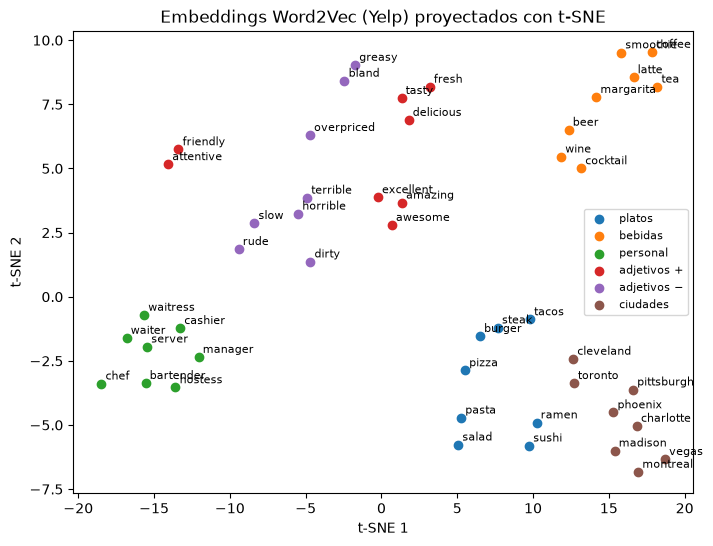

In [9]:
groups = {
    "platos": ["pizza", "burger", "sushi", "ramen", "tacos", "pasta", "steak", "salad"],
    "bebidas": ["coffee", "beer", "wine", "tea", "cocktail", "margarita", "latte", "smoothie"],
    "personal": ["waiter", "waitress", "server", "bartender", "manager", "hostess", "cashier", "chef"],
    "adjetivos +": ["delicious", "amazing", "friendly", "excellent", "tasty", "awesome", "attentive", "fresh"],
    "adjetivos −": ["rude", "bland", "dirty", "terrible", "horrible", "slow", "greasy", "overpriced"],
    "ciudades": ["vegas", "phoenix", "pittsburgh", "charlotte", "montreal", "madison", "toronto", "cleveland"],
}
words = [w for g in groups.values() for w in g]
coords = TSNE(n_components=2, perplexity=8, init="pca", random_state=42).fit_transform(w2v[words])

fig, ax = plt.subplots(figsize=(8, 6))
start = 0
for (group, members), color in zip(groups.items(), plt.cm.tab10.colors):
    xy = coords[start:start + len(members)]
    ax.scatter(xy[:, 0], xy[:, 1], color=color, label=group)
    for (x, y), w in zip(xy, members):
        ax.annotate(w, (x, y), xytext=(3, 3), textcoords="offset points", fontsize=8)
    start += len(members)
ax.set(title="Embeddings Word2Vec (Yelp) proyectados con t-SNE", xlabel="t-SNE 1", ylabel="t-SNE 2")
ax.legend(fontsize=8)
plt.show()

Platos, bebidas, personal y ciudades forman grupos separados: el modelo ha aprendido categorías sin ninguna etiqueta, solo por los contextos. Los adjetivos, en cambio, no se agrupan por **polaridad** sino por **lo que describen**: los de comida (*greasy*, *bland*, *tasty*, *fresh*, *delicious*) juntos arriba, los del servicio (*friendly*, *attentive*, *rude*, *slow*) a la izquierda y los generales (*terrible*, *horrible*, *excellent*, *amazing*) en medio. *bland* está más cerca de *tasty* que de *rude*: los embeddings saben de qué se habla, pero la opinión la recogen solo a medias. Para sentimientos hace falta un clasificador entrenado con etiquetas ([análisis de sentimientos](07-analisis-de-sentimientos.ipynb)).

## 4. Parámetros importantes y errores comunes

| Parámetro (`Word2Vec`) | Qué controla | Valores típicos / consejo |
|---|---|---|
| `sg` | Arquitectura | `1` (*skip-gram*) con corpus pequeños o palabras raras; `0` (CBOW) si prima la velocidad |
| `vector_size` | Dimensión $d$ | 100–300; más dimensiones necesitan más datos |
| `window` | Palabras de contexto a cada lado | 2–5 para vecinos sustituibles (sintácticos); 10 o más para vecinos temáticos |
| `min_count` | Frecuencia mínima | 5–10: con pocas apariciones el vector es casi aleatorio |
| `negative`, `ns_exponent` | Ejemplos negativos y su distribución | 5–20 negativos (más en corpus pequeños); exponente 0,75 |
| `sample` | Submuestreo de palabras muy frecuentes | `1e-3` a `1e-5`; acelera y mejora los vectores de las palabras raras |
| `epochs` | Pasadas por el corpus | 5 por defecto; más en corpus pequeños |
| `workers`, `seed`, `hashfxn` | Paralelismo y reproducibilidad | Reproducible solo con `workers=1`, semilla y *hash* fijo (o `PYTHONHASHSEED`) |

**Errores comunes y lecciones aprendidas**

- **Entrenar dos veces sin querer.** Si se pasan las oraciones al constructor (`Word2Vec(sentences, ...)`), el modelo **ya se entrena** con las épocas por defecto; llamar después a `train()` añade otra ronda completa. En un análisis propio de reseñas de Yelp se hizo así: 5 épocas en el constructor y otras 10 con `train()`, 15 en total, con una tasa de aprendizaje que volvía a empezar desde el valor inicial. O se pasa el corpus al constructor con `epochs=`, o se crea el modelo vacío y se llama a `build_vocab()` y `train()` (demo abajo).
- **Creer que una semilla basta para reproducir el modelo.** En ese análisis se fijó `seed=1` pero con `workers=4`: con varios hilos el resultado cambia en cada ejecución (demo abajo), y entre sesiones también cambia la inicialización salvo que se fije el *hash*. Para comparar ajustes, o se entrena con un hilo y *hash* fijo, o se repite el entrenamiento varias veces y se mira la variación.
- **Lematizar sin la categoría gramatical antes de entrenar.** El lematizador de WordNet trata todo como nombre si no se le pasa la categoría: *us* se convierte en `u`, *was* en `wa` y *has* en `ha`. En el análisis de Yelp apareció `u` (de *us*) entre las palabras del vocabulario de Word2Vec y entre las principales de un tema de LDA. Para embeddings, lo habitual es **no lematizar** (el modelo aprende que *pizza* y *pizzas* son vecinos); si se hace, con la categoría ([preprocesamiento de texto](01-preprocesamiento-de-texto.ipynb)).
- **Leer la similitud como sinonimia.** *good* y *bad* tienen un coseno alto en los dos modelos (demo abajo): los antónimos comparten contextos («*the food was ___*»). Lo que mide el coseno es **similitud distribucional** (palabras que se usan en los mismos contextos, sean sinónimos, antónimos o temas relacionados), no sinonimia; en [detección de temas](05-deteccion-de-temas.ipynb) se compara con la similitud de WordNet. Usar embeddings para ampliar una lista de palabras positivas con sus vecinos mete palabras negativas.
- **Usar vectores generales en un dominio especializado sin comprobarlo.** GloVe pone a *waiter* junto a *housekeeper* y a *vegas* junto a *casino*; en un corpus técnico o médico la diferencia es mayor. Revisa los vecinos de las palabras importantes de la tarea antes de elegir.

In [10]:
# 1) Constructor con corpus + train(): dos entrenamientos completos
small = sentences[:20_000]
twice = Word2Vec(small, vector_size=50, min_count=5, epochs=5, workers=1, seed=42, hashfxn=stable_hash)
twice.train(small, total_examples=len(small), epochs=10)
print("Entrenamientos completos con constructor + train():", twice.train_count)

once = Word2Vec(vector_size=50, min_count=5, workers=1, seed=42, hashfxn=stable_hash)
once.build_vocab(small)
once.train(small, total_examples=once.corpus_count, epochs=15)
print("Con build_vocab() + train():", once.train_count)

# 2) Misma semilla, uno o varios hilos
def train_twice(workers):
    vecs = [Word2Vec(small, vector_size=50, min_count=5, epochs=5, workers=workers, seed=42,
                     hashfxn=stable_hash).wv.vectors for _ in range(2)]
    return np.allclose(*vecs)
print("\n¿Dos entrenamientos idénticos con workers=1?", train_twice(1))
print("¿Dos entrenamientos idénticos con workers=4?", train_twice(4))

# 3) Lematizar sin categoría gramatical
lemmatizer = WordNetLemmatizer()
print("\n", {w: lemmatizer.lemmatize(w) for w in ["us", "was", "has", "pizzas"]})

# 4) Los antónimos quedan cerca
print(f"\nCoseno good-bad: Word2Vec Yelp {w2v.similarity('good', 'bad'):.2f} · GloVe {glove.similarity('good', 'bad'):.2f}")

Entrenamientos completos con constructor + train(): 2


Con build_vocab() + train(): 1



¿Dos entrenamientos idénticos con workers=1? True


¿Dos entrenamientos idénticos con workers=4? False



 {'us': 'u', 'was': 'wa', 'has': 'ha', 'pizzas': 'pizza'}

Coseno good-bad: Word2Vec Yelp 0.67 · GloVe 0.77


## 5. Comparación con métodos relacionados

| Representación | Cómo se obtiene | Ventajas | Inconvenientes | Cuándo usarla |
|---|---|---|---|---|
| [TF-IDF](03-representacion-vectorial-tfidf.ipynb) (una dimensión por palabra) | Recuentos ponderados | Interpretable, sin entrenamiento, muy buena con modelos lineales | Dispersa; sin noción de sinónimos | Clasificación y búsqueda con datos suficientes |
| WordNet | Hecho a mano por lingüistas | Relaciones explícitas (hiperónimos, sinónimos); distingue sentidos | Cobertura limitada; sin jerga ni palabras nuevas | Similitud taxonómica, ampliar consultas ([temas](05-deteccion-de-temas.ipynb)) |
| Word2Vec propio | Predecir el contexto en el corpus propio | Aprende la jerga y los compuestos del dominio | Necesita millones de palabras; vectores pobres para palabras raras | Dominio con vocabulario propio y mucho texto sin etiquetar |
| GloVe / Word2Vec preentrenados | Igual, con miles de millones de palabras | Robustos; vocabulario enorme; sin entrenar | Uso general; OOV para palabras del dominio | Punto de partida por defecto; pocos datos |
| FastText | Word2Vec con n-gramas de caracteres | Vectores para palabras no vistas y con errores; buen rendimiento con morfología rica | Modelos más grandes | Texto con errores, idiomas con mucha flexión (español, finés) |
| Embeddings contextuales ([BERT](10-modelos-de-lenguaje-preentrenados.ipynb)) | *Transformer* preentrenado | Un vector distinto según el contexto (resuelve la polisemia) | Mucho más costosos | Cuando el rendimiento importa más que el coste |

## 6. Referencias

### Fuentes

- Zhang, X., Zhao, J. y LeCun, Y. (2015). «Character-level convolutional networks for text classification». *Advances in Neural Information Processing Systems 28 (NIPS 2015)*, 649–657. Origen de Yelp Review Full, descargado de Hugging Face ([`Yelp/yelp_review_full`](https://huggingface.co/datasets/Yelp/yelp_review_full)) con [`datasets.load_dataset`](https://huggingface.co/docs/datasets/loading).
- Pennington, J., Socher, R. y Manning, C. D. (2014). «GloVe: Global Vectors for Word Representation». *Proceedings of EMNLP 2014*, 1532–1543. Vectores [GloVe](https://nlp.stanford.edu/projects/glove/) (`glove.6B.100d`), descargados en formato de gensim desde [`fse/glove-wiki-gigaword-100`](https://huggingface.co/fse/glove-wiki-gigaword-100) con [`hf_hub_download`](https://huggingface.co/docs/huggingface_hub/guides/download).
- gensim: [`models.word2vec`](https://radimrehurek.com/gensim/models/word2vec.html), [`models.keyedvectors`](https://radimrehurek.com/gensim/models/keyedvectors.html) (similitud, analogías y `evaluate_word_pairs` / `evaluate_word_analogies` con WordSim-353 y las analogías de Google) y [`models.phrases`](https://radimrehurek.com/gensim/models/phrases.html).
- NLTK: [`nltk.stem`](https://www.nltk.org/api/nltk.stem.html) (lematizador de WordNet).
- scikit-learn: [`TSNE`](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html).

### Para saber más

- Mikolov, T., Sutskever, I., Chen, K., Corrado, G. y Dean, J. (2013). «Distributed representations of words and phrases and their compositionality». *Advances in Neural Information Processing Systems 26 (NIPS 2013)*, 3111–3119. El artículo de Word2Vec más citado: *skip-gram* con muestreo negativo, submuestreo de palabras frecuentes y detección de frases (la fórmula que usa `Phrases`).
- Jurafsky, D. y Martin, J. H. (2026). [*Speech and Language Processing*](https://web.stanford.edu/~jurafsky/slp3/) (3.ª ed., borrador en línea). El capítulo 5 (*Embeddings*) explica la semántica vectorial desde TF-IDF y PPMI hasta Word2Vec, sus propiedades (analogías, sesgos) y su evaluación.